<a href="https://colab.research.google.com/github/Zsoltee/MachineLearning_Python/blob/main/K-means_clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

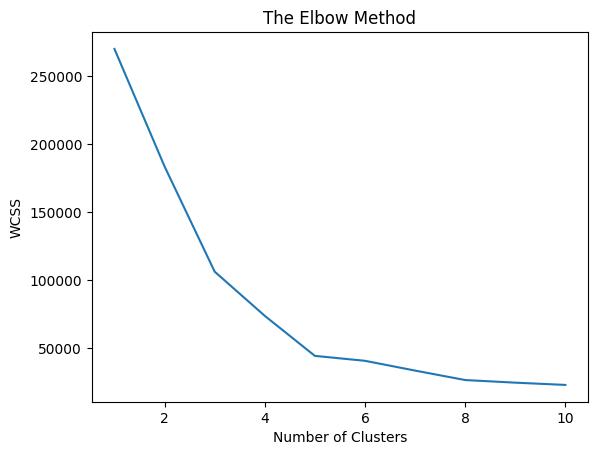

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

dataset = pd.read_csv('/content/Mall_Customers.csv')

X = dataset.iloc[:, [3, 4]].values

from sklearn.cluster import KMeans
wcss = []
for i in range (1, 11):
    kmeans = KMeans(n_clusters = i, init = 'k-means++', random_state = 42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)
plt.plot(range(1, 11),wcss)
plt.title('The Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()



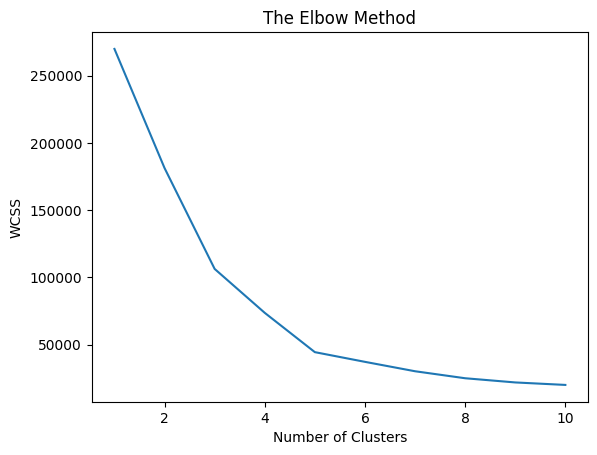

A modell betanítva, az y_kmeans készen van!


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.cluster import KMeans

# 1. Adat beolvasása (Figyelj az elérési útra!)
dataset = pd.read_csv('/content/Mall_Customers.csv')

# 2. X definiálása (EZ VOLT A HIBA: ki kell jelölni az oszlopokat)
# Annual Income (3. oszlop) és Spending Score (4. oszlop)
X = dataset.iloc[:, [3, 4]].values

# 3. Elbow Method (Hogy lásd a grafikont)
wcss = []
for i in range(1, 11):
    # A n_init='auto' vagy n_init=10 segít elkerülni a figyelmeztetéseket
    kmeans = KMeans(n_clusters = i, init = 'k-means++', n_init=10, random_state = 42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss)
plt.title('The Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()

# 4. Tanítás a legjobb (5) klaszterrel
kmeans = KMeans(n_clusters = 5, init = 'k-means++', n_init=10, random_state = 42)
y_kmeans = kmeans.fit_predict(X)

print("A modell betanítva, az y_kmeans készen van!")

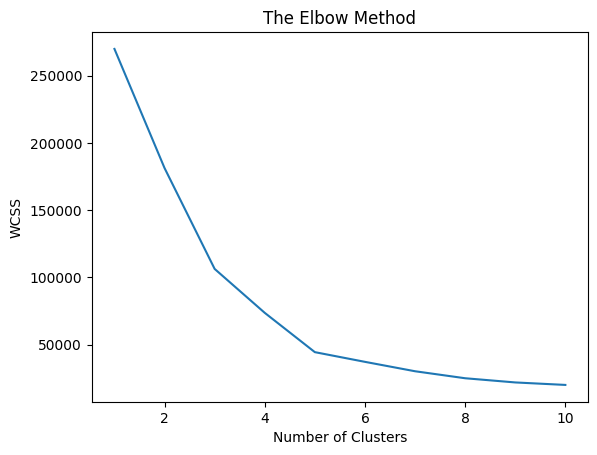

A csoportosítás elkészült!
[4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4
 2 4 2 4 2 4 0 4 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 1 3 1 0 1 3 1 3 1 0 1 3 1 3 1 3 1 3 1 0 1 3 1 3 1
 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3
 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1]


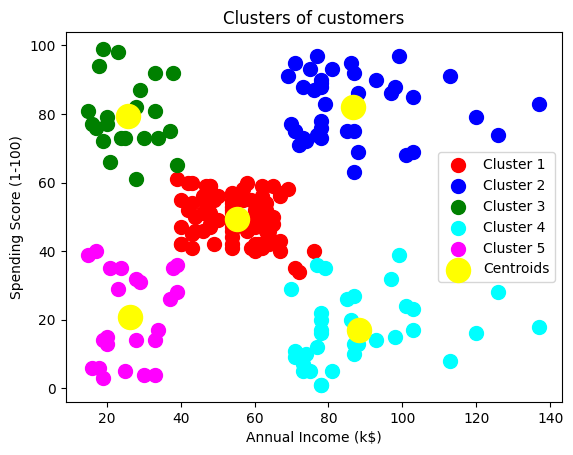

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.cluster import KMeans

# 1. Adat beolvasása
dataset = pd.read_csv('Mall_Customers.csv')

# 2. X definiálása (Éves jövedelem és Költési pontszám)
X = dataset.iloc[:, [3, 4]].values

# 3. Elbow Method (Az optimális k meghatározása)
wcss = []
for i in range(1, 11):
    # n_init=10 hozzáadva, hogy ne legyen figyelmeztetés
    kmeans = KMeans(n_clusters = i, init = 'k-means++', n_init=10, random_state = 42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

# Grafikon megjelenítése
plt.plot(range(1, 11), wcss)
plt.title('The Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()

# 4. Modell tanítása (5 klaszterrel, mert ott a könyök)
kmeans = KMeans(n_clusters = 5, init = 'k-means++', n_init=10, random_state = 42)
y_kmeans = kmeans.fit_predict(X)

# Kiírjuk az eredményt, hogy lásd, működik
print("A csoportosítás elkészült!")
print(y_kmeans)

# 5. A klaszterek megjelenítése (Visualising the clusters)
plt.scatter(X[y_kmeans == 0, 0], X[y_kmeans == 0, 1], s = 100, c = 'red', label = 'Cluster 1')
plt.scatter(X[y_kmeans == 1, 0], X[y_kmeans == 1, 1], s = 100, c = 'blue', label = 'Cluster 2')
plt.scatter(X[y_kmeans == 2, 0], X[y_kmeans == 2, 1], s = 100, c = 'green', label = 'Cluster 3')
plt.scatter(X[y_kmeans == 3, 0], X[y_kmeans == 3, 1], s = 100, c = 'cyan', label = 'Cluster 4')
plt.scatter(X[y_kmeans == 4, 0], X[y_kmeans == 4, 1], s = 100, c = 'magenta', label = 'Cluster 5')

# A csoportok középpontjai (Centroids)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s = 300, c = 'yellow', label = 'Centroids')

plt.title('Clusters of customers')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.show()